In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
stock_data = yf.download('AAPL',start='2024-01-01')
stock_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.903229,186.677036,182.169601,185.399096,82488700
2024-01-03,182.526230,184.140985,181.713894,182.496512,58414500
2024-01-04,180.208130,181.377083,179.187767,180.445875,71983600
2024-01-05,179.484955,181.050175,178.484409,180.287390,62379700
2024-01-08,183.823975,183.863609,179.801961,180.386437,59144500


In [3]:
log_ts = np.log(stock_data['Close'])
print(stock_data['Close'].std(), log_ts.std())

Ticker
AAPL    29.480504
dtype: float64 Ticker
AAPL    0.135538
dtype: float64


In [4]:
def additive_or_multiplicative(ts, window=30):
    ts = pd.Series(ts).dropna().astype(float)

    df = pd.DataFrame({'y': ts.values})
    df['group'] = np.arange(len(df)) // window

    stats = df.groupby('group')['y'].agg(['mean', 'var'])

    # drop groups with zero variance
    stats = stats[(stats['mean'] > 0) & (stats['var'] > 0)]

    corr = stats['mean'].corr(stats['var'])
    return corr

In [5]:
corr = additive_or_multiplicative(stock_data['Close'].values.ravel())
print(corr)

0.10729874570615779


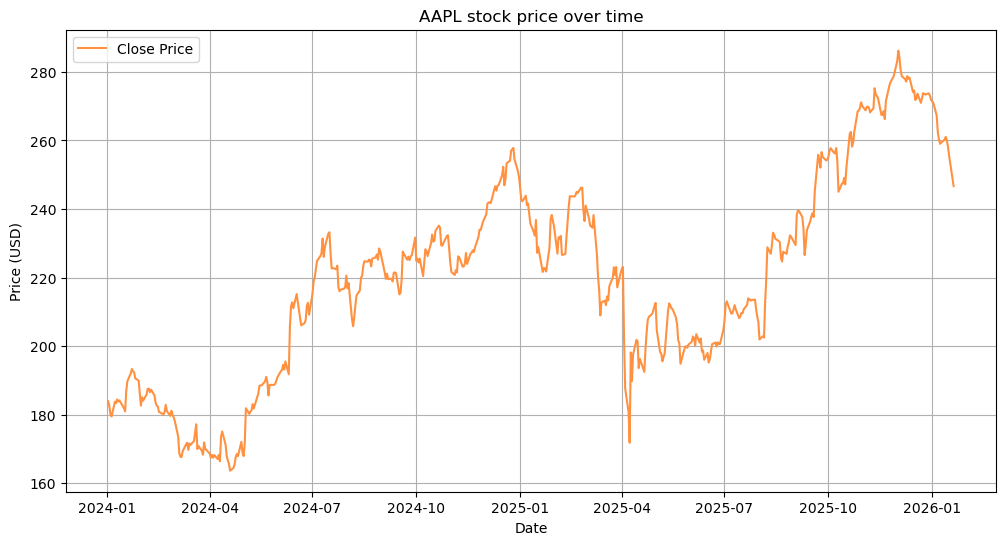

In [6]:
plt.figure(figsize=(12,6))
plt.plot(stock_data.index,stock_data['Close'],label='Close Price',color='#FF9140')
plt.title('AAPL stock price over time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Classical time series decomposition

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
decomposition = seasonal_decompose(stock_data['Close'],model='additive',period=30)

In [10]:
trend = decomposition.trend
seasonality = decomposition.seasonal
residual = decomposition.resid

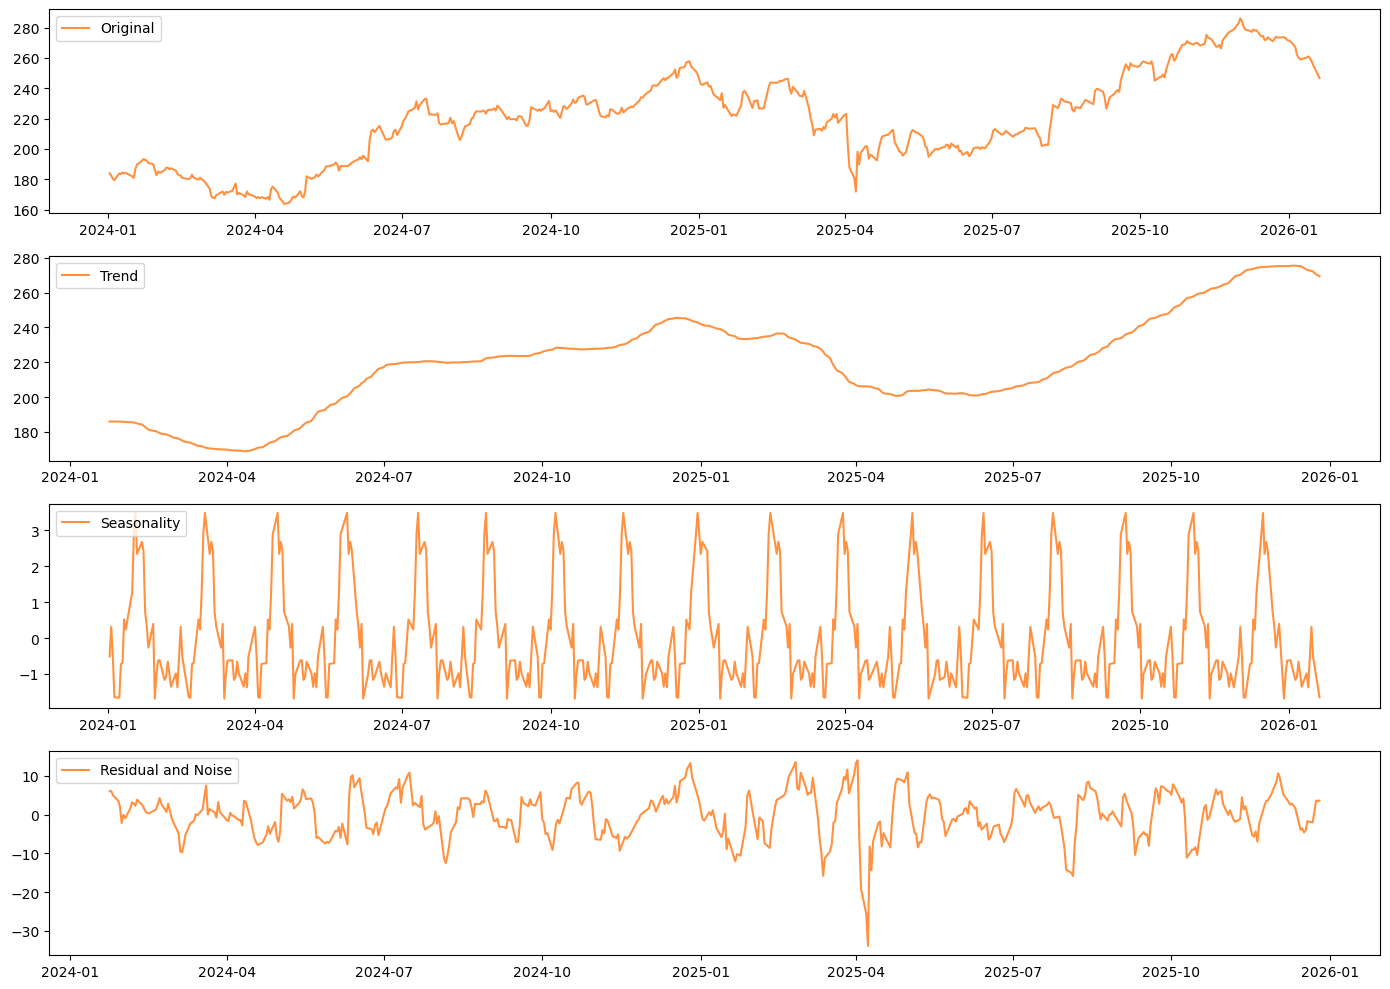

In [11]:
plt.figure(figsize=(14,10))
plt.subplot(411)
plt.plot(stock_data['Close'],label='Original',color='#FF9140')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend,label='Trend',color='#FF9140')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonality,label='Seasonality',color='#FF9140')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual,label='Residual and Noise',color='#FF9140')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# STL implementation

In [13]:
from statsmodels.tsa.seasonal import STL

In [14]:
stl = STL(stock_data['Close'],period=30)
result = stl.fit()

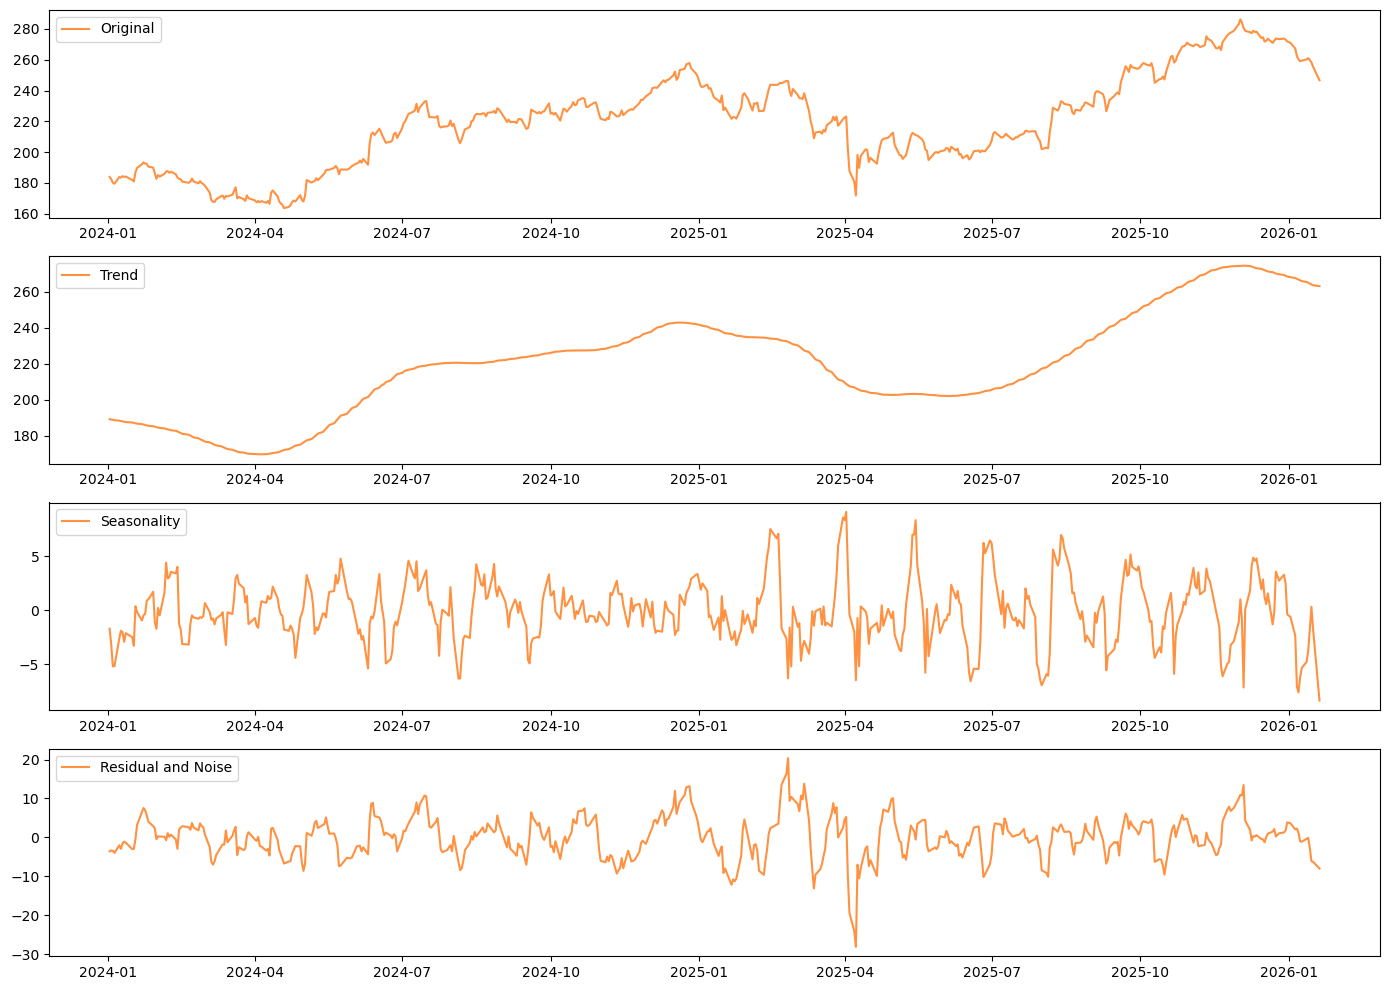

In [15]:
plt.figure(figsize=(14,10))
plt.subplot(411)
plt.plot(result.observed,label='Original',color='#FF9140')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(result.trend,label='Trend',color='#FF9140')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(result.seasonal,label='Seasonality',color='#FF9140')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(result.resid,label='Residual and Noise',color='#FF9140')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('my_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Stationarity

## Types of stationarity
    1. Weak stationarity = ADF test (Augmented Dickey-Fuller), KPSS test (Kwiatkowski-Phillips-Schmidt-Shin)
    2. Strict stationarity = KS test (Two-Sample Kolmogorov-Smirnov (KS) test)

## Detection criteria
### ADF test = p_value < 0.05 or ADF_stats < CRITICAL VALUE then it is stationary data
### KPSS test = p_value < 0.05 or KPSS_stats > CRITICAL VALUE then it is non-stationary data
### KS test = p_value > 0.05 then it is a stationary data

In [19]:
from statsmodels.tsa.stattools import adfuller
# Perform the Augmented Dickey—Ful ler
adf_test = adfuller(stock_data['Close'])
print('ADF Test Results:')
print(f'ADF Statistic: {round(adf_test[0],3)}')
print(f'p—value: {round(adf_test[1],3)}')
print( 'Critical Values: ' )
for key, value in adf_test [4].items():
    print (f' {key}:{round(value,3)}')

ADF Test Results:
ADF Statistic: -1.682
p—value: 0.44
Critical Values: 
 1%:-3.443
 5%:-2.867
 10%:-2.57


## Observation : By looking to the p_value , adf stats and critical value  the data is not stationary data

In [21]:
warnings.filterwarnings('ignore')
from statsmodels.tsa.stattools import kpss
# Perform the KPSS test
kpss_test = kpss(stock_data['Close'],regression='ct')
print('KPSS TEST RESULTS: ')
print(f'KPSS stats : {round(kpss_test[0],2)}')
print(f'p_value : {kpss_test[1]}')
print('Critical Values')
for key , value in kpss_test[3].items():
    print(f' {key}:{value}')



KPSS TEST RESULTS: 
KPSS stats : 0.29
p_value : 0.01
Critical Values
 10%:0.119
 5%:0.146
 2.5%:0.176
 1%:0.216


## Observations : p_value is less 0.05 so not stationary data also the kpss stats are greater than the critical values so also it is **NOT** STATIONARY DATA

## Now we will see how actual we perform these using synthetic data generation

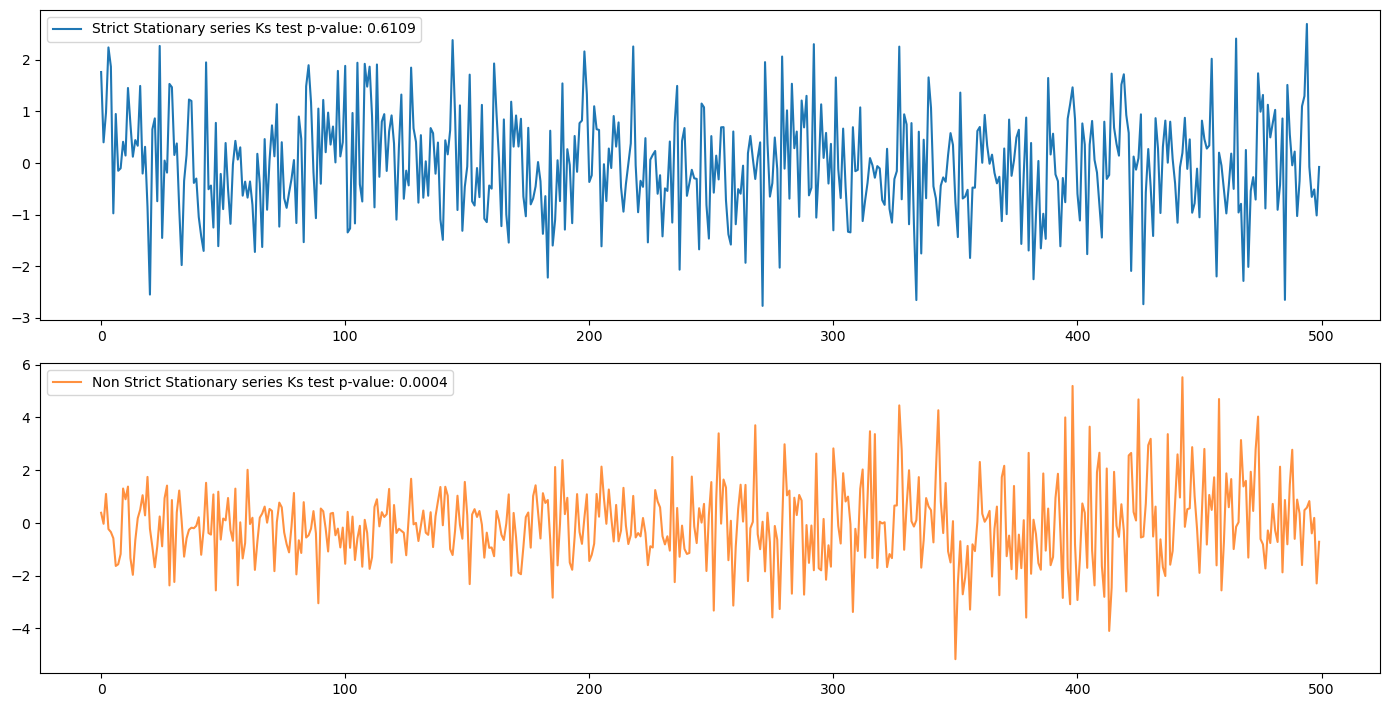

Strict stationary series - K-S Test Statistic: 0.068, p-value:0.6109
Weak stationary series - K-S Test Statistic: 0.184, p-value:0.0004


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
#Generating synthetic data for demonstration
np.random.seed(0)
n = 500
# Strictly stationary series: normally distributed random noise
strict_stationary_series = np.random.normal(0, 1, n)
# Non-strictly stationary series: changing variance
non_strict_stationary_series = np.concatenate([
np.random.normal(0, 1, n // 2),
np.random.normal(0, 2, n // 2)
])
# Function to split the series into two halves and perform the K-S test
def ks_test_stationarity (series):
    split = len(series) // 2
    series_first_half = series[:split]
    series_second_half = series[split:]
    stat, p_value = ks_2samp(series_first_half, series_second_half)
    return stat, p_value
# Perform the K-S test on strictly stationary series
ks_stat_strict, ks_pvalue_strict = ks_test_stationarity (strict_stationary_series)
# Perform the K-S test on non-strictly stationary series
ks_stat_non_strict, ks_pvalue_non_strict = ks_test_stationarity (non_strict_stationary_series)
# Plotting the series
plt.figure(figsize=(14, 14))
plt.subplot(411)
plt.plot(strict_stationary_series,label=f"Strict Stationary series Ks test p-value: {round(ks_pvalue_strict,4)}")
plt.legend(loc="upper left")
plt.subplot(412)
plt.plot(non_strict_stationary_series,label=f"Non Strict Stationary series Ks test p-value: {round(ks_pvalue_non_strict,4)}", color='#FF9140')
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()
print(f'Strict stationary series - K-S Test Statistic: {ks_stat_strict}, p-value:{ks_pvalue_strict:.4f}')
print(f'Weak stationary series - K-S Test Statistic: {ks_stat_non_strict}, p-value:{ks_pvalue_non_strict:.4f}')

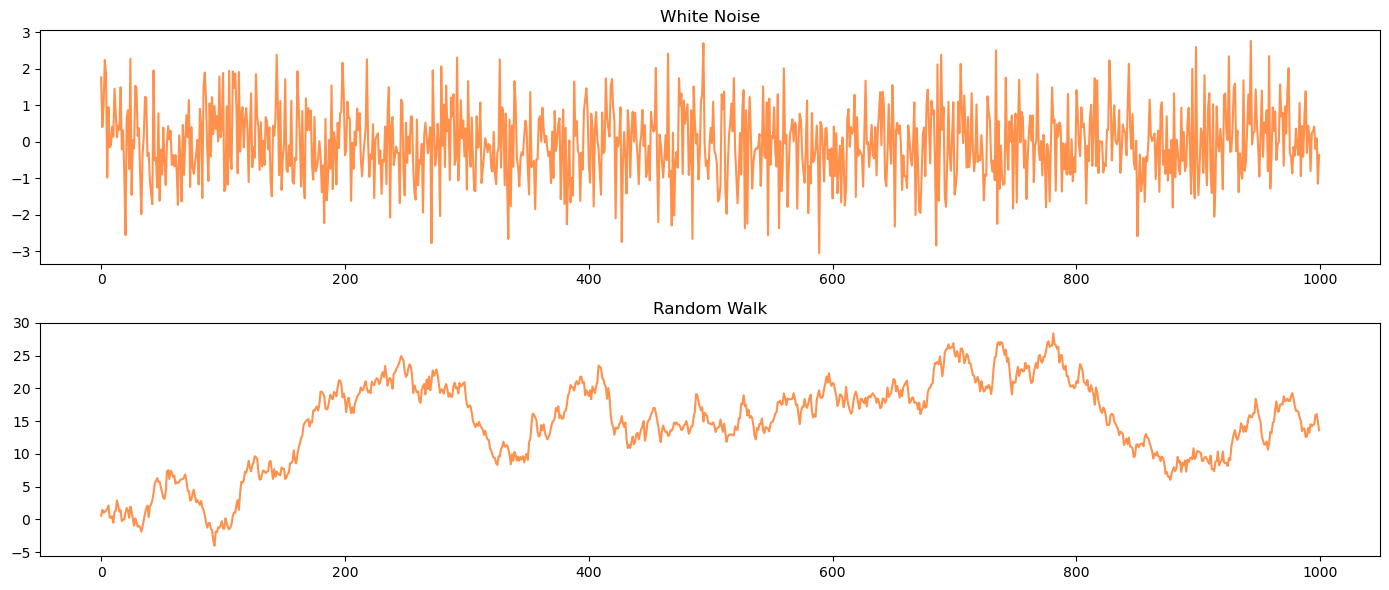


Ljung-Box Test for White Noise:
      lb_stat  lb_pvalue
10  14.025574   0.171828

Ljung-Box Test for Random Walk:
        lb_stat  lb_pvalue
10  8828.660312        0.0


In [43]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

# Generating white noise and random walk for comparison
n = 1000
np.random.seed(0)

# White Noise
white_noise = np.random.normal(0, 1, n)

# Random Walk
random_shocks = np.random.normal(0, 1, n)
random_walk = np.cumsum(random_shocks)

# Plotting the series
plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
plt.plot(white_noise, color = '#FF914D')
plt.title(f'White Noise')

plt.subplot(2, 1, 2)
plt.plot(random_walk, color = '#FF914D')
plt.title(f'Random Walk')

plt.tight_layout()
plt.show()

# Ljung-Box test
print("\nLjung-Box Test for White Noise:")
lb_test_white_noise = acorr_ljungbox(white_noise, lags=[10], return_df=True)
print(lb_test_white_noise)
print("\nLjung-Box Test for Random Walk:")
lb_test_random_walk = acorr_ljungbox(random_walk, lags=[10], return_df=True)
print(lb_test_random_walk)
